## Notebook for selection of validation sites and events

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go

import sim_ranking as sr



In [2]:
obs_data_ffp = Path("/Users/claudy/dev/work/data/gm_datasets/nz_gmdb/v3.0/Tables/ground_motion_im_table_rotd50_flat.csv")

In [3]:
obs_data = sr.ObservedData.from_nzgmdb_flat(obs_data_ffp)
site_df = obs_data.site_df.copy().dropna(axis=0)

record_df = obs_data.record_df.copy()
record_df = record_df.loc[record_df.site_id.isin(site_df.index)]
record_df = record_df.loc[record_df.rjb < 150]
print(f"Number of records: {len(record_df)}")
print(f"Number of events: {len(record_df.event_id.unique())}")


site_event_counts = record_df.groupby("site_id").size()    
site_df.loc[site_event_counts.index, "n_events"] = site_event_counts.values


Number of records: 70625
Number of events: 5346


### Split the sites into bins based on Vs30

In [4]:
vs30_bins = [0, 180, 360, 760, 1000, 1500]
soil_classes = ["SoftSoil", "StiffSoil", "DenseSoilSoftRock", "Rock", "HardRock"]
site_df.loc[:, "vs30_class"] = pd.cut(site_df["vs30"], bins=vs30_bins, labels=soil_classes)

In [5]:
site_df["vs30_class"].value_counts()

vs30_class
DenseSoilSoftRock    253
StiffSoil            181
Rock                  81
HardRock              15
SoftSoil              13
Name: count, dtype: int64

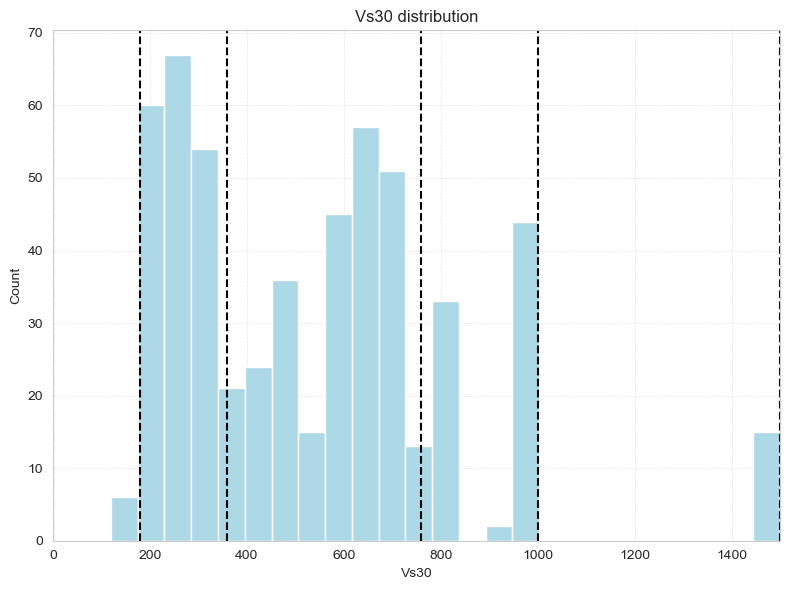

In [6]:
n_bins = 25

fig, ax = plt.subplots(figsize=(8, 6))
plt.hist(site_df["vs30"], bins=n_bins, color="lightblue", label="vs30")

for vs30_bin in vs30_bins:
	plt.axvline(vs30_bin, color="k", linestyle="--")

plt.title(f"Vs30 distribution")
plt.xlabel(f"Vs30")
plt.ylabel(f"Count")
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.xlim(0, 1500)
plt.tight_layout()


### Select sites

In [7]:
site_df.groupby("vs30_class", observed=True).size()

vs30_class
SoftSoil              13
StiffSoil            181
DenseSoilSoftRock    253
Rock                  81
HardRock              15
dtype: int64

In [8]:
def select_sites(site_df, soil_class, n_sites, top_n=20):
    cur_site_df = site_df.loc[site_df.vs30_class == soil_class].sort_values("n_events", ascending=False)
    cur_sel_sites = np.random.choice(cur_site_df.head(top_n).index, n_sites, replace=False)
    return cur_sel_sites

In [9]:
def vis_mag_rrup_dist(sites, record_df, title):
	cur_record_df = record_df.loc[record_df.site_id.isin(sites)]
    
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
	ax1.hist(cur_record_df.mag, bins=20, color="lightblue", label="Magnitude")
	ax1.set_xlabel(f"Magnitude")
	ax1.set_ylabel(f"Count")
	ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	
	ax2.hist(cur_record_df.rrup, bins=20, color="lightblue", label="$R_{rup}$")
	ax2.set_xlabel("$R_{rup}$")
	ax2.set_ylabel(f"Count")
	ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	
	fig.suptitle(title)
	fig.tight_layout()


### Soft Soil

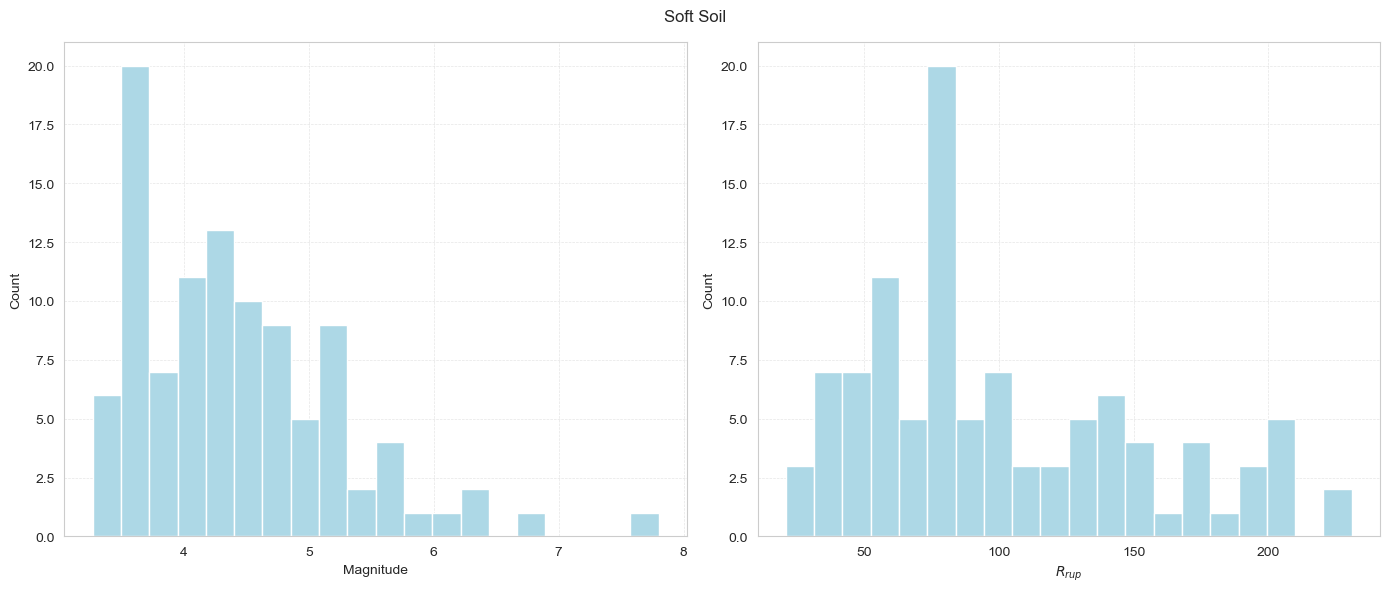

In [10]:
### Soft Soil
np.random.seed(20)
n_sites = 3

soft_soil_sites = select_sites(site_df, "SoftSoil", n_sites)
soft_soil_events = record_df.loc[record_df.site_id.isin(soft_soil_sites)]
vis_mag_rrup_dist(soft_soil_sites, record_df, title="Soft Soil")



In [11]:
record_df.loc[record_df.site_id.isin(soft_soil_sites)].groupby("site_id").size()

site_id
GWTS    14
WDAS    74
WFSS    14
dtype: int64

### Stiff soil

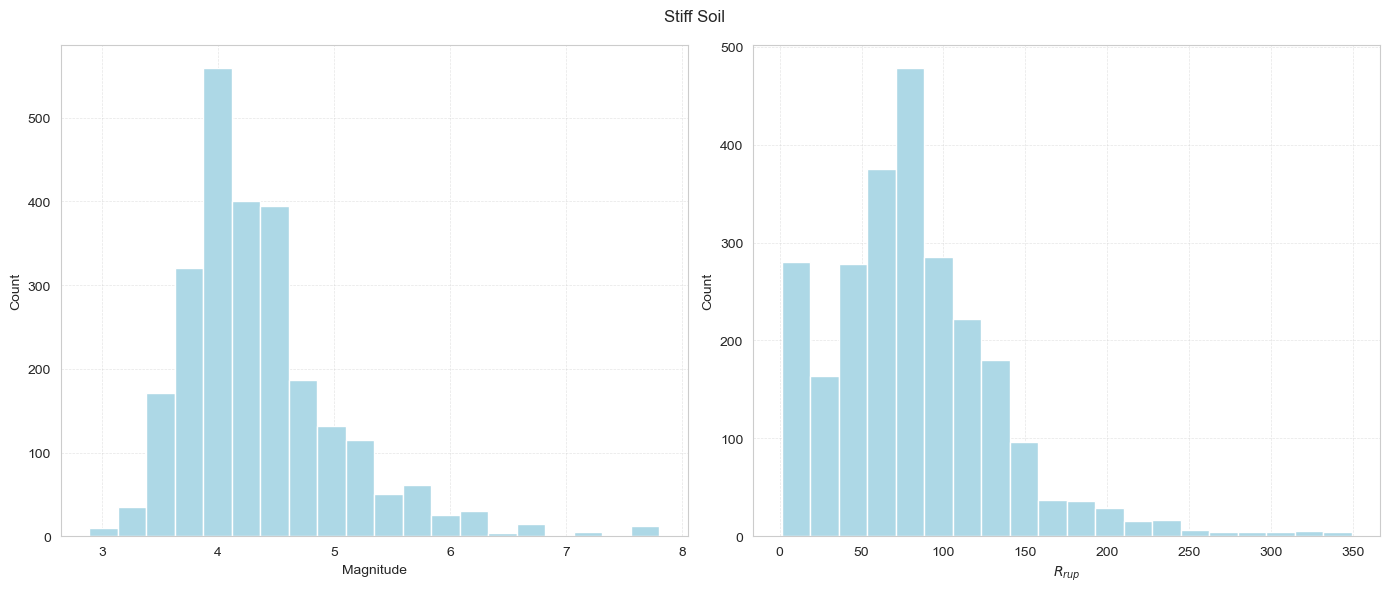

In [12]:
### Stiff soil
np.random.seed(21)
n_sites = 25

stiff_soil_sites = select_sites(site_df, "StiffSoil", n_sites, top_n=150)
stiff_soil_events = record_df.loc[record_df.site_id.isin(stiff_soil_sites)]
vis_mag_rrup_dist(stiff_soil_sites, record_df, "Stiff Soil")

In [13]:
record_df.loc[record_df.site_id.isin(stiff_soil_sites)].groupby("site_id").size()

site_id
ASHS    228
AWRB     26
CUBS     72
GCSZ     30
HMCS     13
HOCS     66
HPSC     71
HVSC    207
HWHS     12
LINC     83
LRSS    114
MUGZ    202
NBLC     58
OPCS     73
PGFS     54
POKS    270
POLS    192
PVCS    110
RCS1     52
SCAC     71
SEAS    216
SOCS    205
TAFS     65
TKHS     10
WBCS     26
dtype: int64

### Dense Soil & Soft Rock

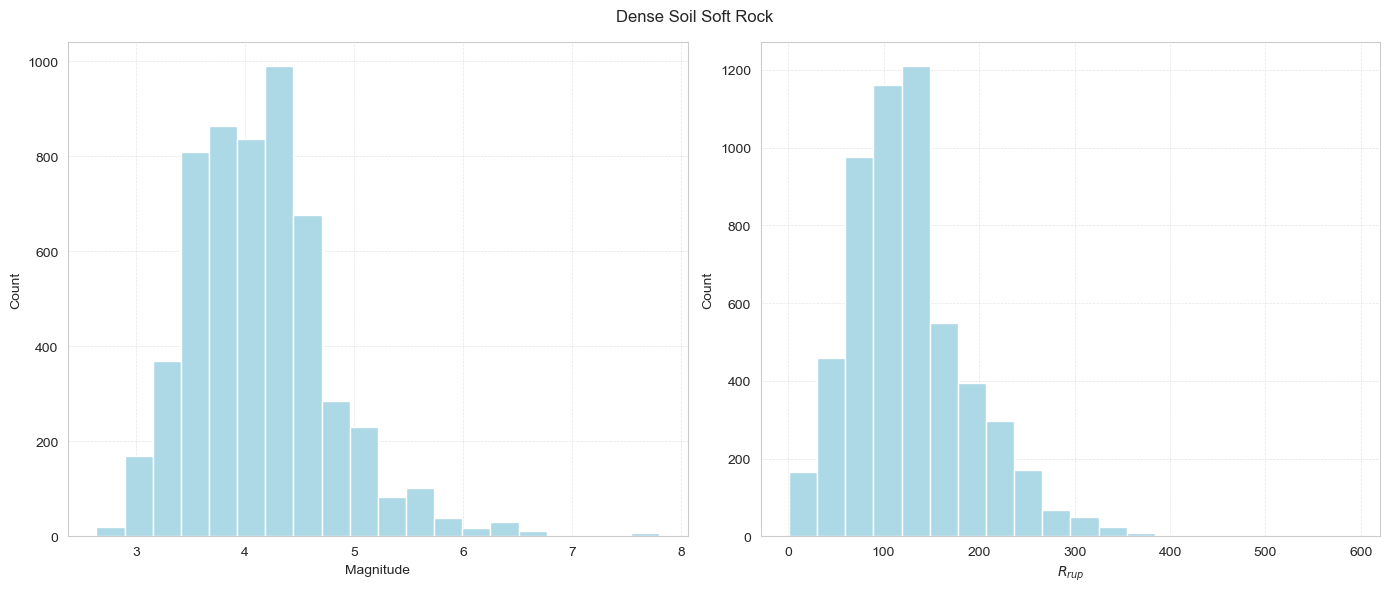

In [14]:
### DenseSoilSoftRock
np.random.seed(23)
n_sites = 35

dense_soil_soft_rock_sites = select_sites(site_df, "DenseSoilSoftRock", n_sites, top_n=200)
dense_soil_soft_rock_events = record_df.loc[record_df.site_id.isin(dense_soil_soft_rock_sites)]
vis_mag_rrup_dist(dense_soil_soft_rock_sites, record_df, "Dense Soil Soft Rock")

In [15]:
record_df.loc[record_df.site_id.isin(dense_soil_soft_rock_sites)].groupby("site_id").size()

site_id
BFZ     245
COVZ     91
DHSS    107
FOZ      67
GDLC     31
HAZ     454
INSS    139
KARZ    171
KNGC     35
KQ03     50
KRVZ    176
LHBS    353
MARZ    178
MAVZ     98
MCAS     40
MHCZ     89
MKRZ     61
MKVS    416
MSZS     31
NELS    225
NGRZ     37
NNVZ     55
OIZ     132
OPRZ    270
PKGZ    416
PREZ     65
RITZ    111
SNGZ    182
SUMS     94
TSFS     70
UHCS    242
WAZ     380
WHHZ    120
WIZ     168
WPVZ    147
dtype: int64

### Rock

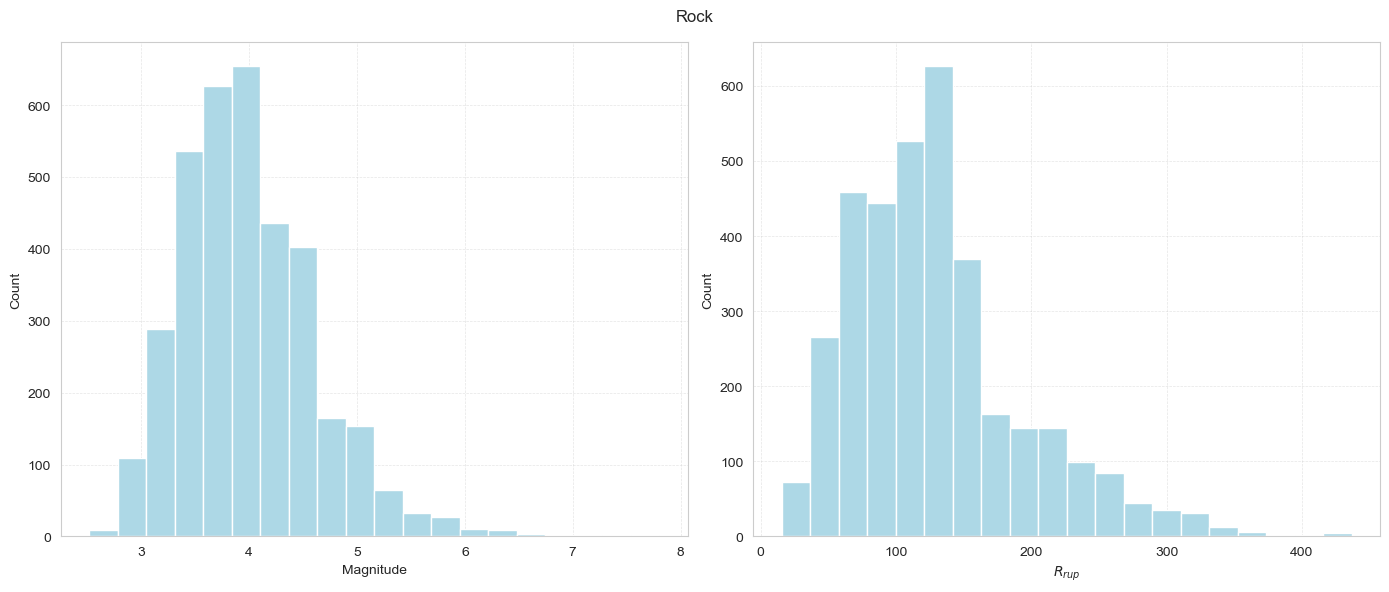

In [16]:
### Rock
np.random.seed(20)
n_sites = 10

rock_sites = select_sites(site_df, "Rock", n_sites, top_n=50)
rock_events = record_df.loc[record_df.site_id.isin(rock_sites)]
vis_mag_rrup_dist(rock_sites, record_df, "Rock")

In [17]:
record_df.loc[record_df.site_id.isin(rock_sites)].groupby("site_id").size()

site_id
HRRZ     64
KWHZ    241
MWZ     649
MXZ     775
OGWZ    525
PYZ     352
RPZ     228
TIWZ    236
TSZ     390
WBFS     74
dtype: int64

### Hard Rock

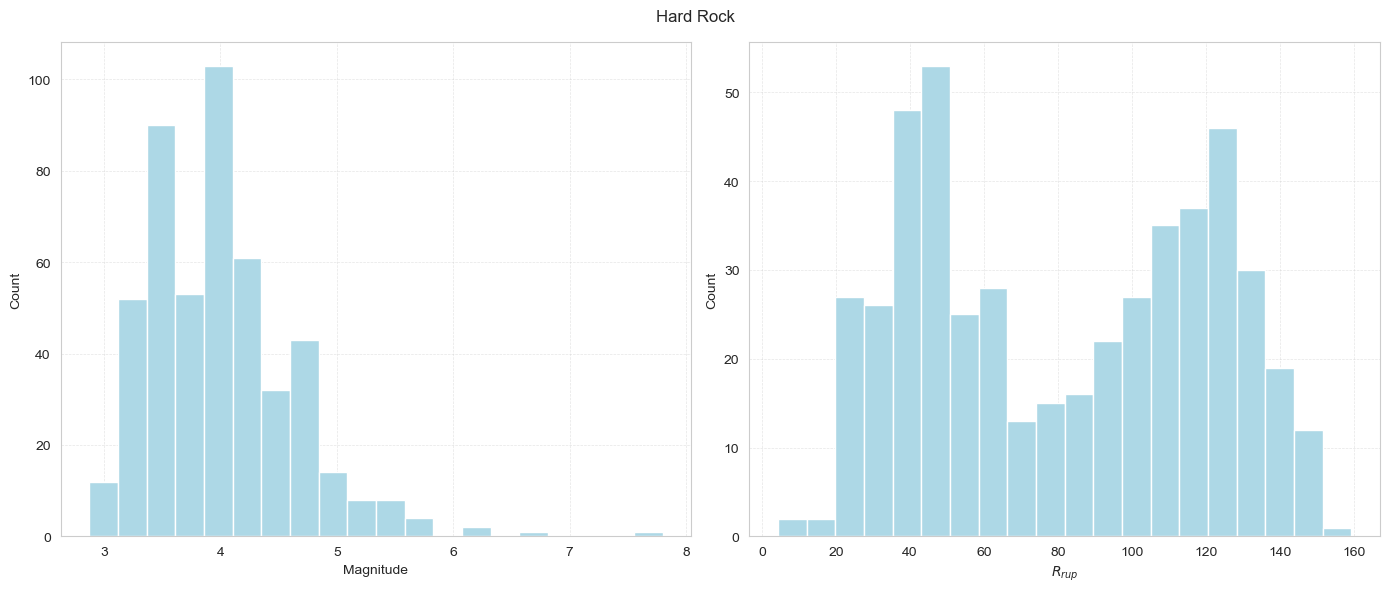

In [18]:
### HardRock
np.random.seed(20)
n_sites = 4

hard_rock_sites = select_sites(site_df, "HardRock", n_sites)
hard_rock_events = record_df.loc[record_df.site_id.isin(hard_rock_sites)]
vis_mag_rrup_dist(hard_rock_sites, record_df, "Hard Rock")

In [19]:
record_df.loc[record_df.site_id.isin(hard_rock_sites)].groupby("site_id").size()

site_id
CSBF     13
DCZ     441
DECF     30
dtype: int64

In [38]:
val_int_sites = np.concatenate([soft_soil_sites, stiff_soil_sites, dense_soil_soft_rock_sites, rock_sites, hard_rock_sites])

# Manual mods
add_sites = ["CCPS", "PKE", "PPHS", "WSFC", "LBZ", "OKCZ", "WIGC", "NGHS", "BOWS", "AKUS", "KUTZ", "MOLS"]
remove_sites = ["KARZ", "MARZ", "NNVZ", "DECF", "WPVZ", "MKRZ"]

val_int_sites = np.concatenate([val_int_sites, add_sites])
val_int_sites = np.setdiff1d(val_int_sites, remove_sites)

In [39]:
### Spatial distribution of selected sites
remaining_sites = site_df.index.difference(np.concatenate([soft_soil_sites, stiff_soil_sites, dense_soil_soft_rock_sites, rock_sites, hard_rock_sites]))
template = "<b>Name: %{customdata.site}<br>Vs30: %{customdata.vs30}<br>Z1.0: %{customdata.z1p0}<br>Soil Class: %{customdata.soil_class}<extra></extra>"

fig = go.Figure(
    data=[
        go.Scattermapbox(
                lat=site_df.loc[remaining_sites].lat,
				lon=site_df.loc[remaining_sites].lon,
				mode="markers",
				marker=dict(size=10, color="black"),
				hovertemplate=template,
				customdata=[
                                                {
						"site": cur_site,
						"vs30": site_df.loc[cur_site, "vs30"],
						"z1p0": site_df.loc[cur_site, "z1p0"],
                        "soil_class": site_df.loc[cur_site, "vs30_class"],
					}
					for cur_site in remaining_sites
				],
                name="Remaining",
        	),
        go.Scattermapbox(
            lat=site_df.loc[soft_soil_sites].lat,
            lon=site_df.loc[soft_soil_sites].lon,
            mode="markers",
            marker=dict(size=10, color="blue"),
            hovertemplate="<b>Name: %{customdata.site}<br>Vs30: %{customdata.vs30}<br>Z1.0: %{customdata.z1p0}<extra></extra>",
            customdata=[
                {
                    "site": cur_site,
                    "vs30": site_df.loc[cur_site, "vs30"],
                    "z1p0": site_df.loc[cur_site, "z1p0"],
                }
                for cur_site in soft_soil_sites
            ],
            name="Soft Soil",
        ),
        go.Scattermapbox(
            lat=site_df.loc[stiff_soil_sites].lat,
			lon=site_df.loc[stiff_soil_sites].lon,
			mode="markers",
			marker=dict(size=10, color="red"),
			hovertemplate="<b>Name: %{customdata.site}<br>Vs30: %{customdata.vs30}<br>Z1.0: %{customdata.z1p0}<extra></extra>",
			customdata=[
				{
					"site": cur_site,
					"vs30": site_df.loc[cur_site, "vs30"],
					"z1p0": site_df.loc[cur_site, "z1p0"],
				}
				for cur_site in stiff_soil_sites
			],
			name="Stiff Soil",
		),
        go.Scattermapbox(
            lat=site_df.loc[dense_soil_soft_rock_sites].lat,
            lon=site_df.loc[dense_soil_soft_rock_sites].lon,
            mode="markers",
            marker=dict(size=10, color="green"),
            hovertemplate="<b>Name: %{customdata.site}<br>Vs30: %{customdata.vs30}<br>Z1.0: %{customdata.z1p0}<extra></extra>",
            customdata=[
				{
					"site": cur_site,
					"vs30": site_df.loc[cur_site, "vs30"],
					"z1p0": site_df.loc[cur_site, "z1p0"],
				}
				for cur_site in dense_soil_soft_rock_sites
			],
            name="Dense Soil & Soft Rock",
		),
        go.Scattermapbox(
			lat=site_df.loc[rock_sites].lat,
			lon=site_df.loc[rock_sites].lon,
			mode="markers",
			marker=dict(size=10, color="purple"),
			hovertemplate="<b>Name: %{customdata.site}<br>Vs30: %{customdata.vs30}<br>Z1.0: %{customdata.z1p0}<extra></extra>",
			customdata=[
				{
					"site": cur_site,
					"vs30": site_df.loc[cur_site, "vs30"],
					"z1p0": site_df.loc[cur_site, "z1p0"],
				}
                				for cur_site in rock_sites
                			],
            name="Rock",
		),
        go.Scattermapbox(
            			lat=site_df.loc[hard_rock_sites].lat,
            			lon=site_df.loc[hard_rock_sites].lon,
            			mode="markers",
            			marker=dict(size=10, color="orange"),
            			hovertemplate="<b>Name: %{customdata.site}<br>Vs30: %{customdata.vs30}<br>Z1.0: %{customdata.z1p0}<extra></extra>",
            			customdata=[
							{
								"site": cur_site,
								"vs30": site_df.loc[cur_site, "vs30"],
								"z1p0": site_df.loc[cur_site, "z1p0"],
							}
							for cur_site in hard_rock_sites
						],
            			name="Hard Rock",
					),
                go.Scattermapbox(
            lat=site_df.loc[add_sites].lat,
            lon=site_df.loc[add_sites].lon,
            mode="markers",
            marker=dict(size=10, color="turquoise"),
            hovertemplate=template,
            customdata=[
				{
					"site": cur_site,
					"vs30": site_df.loc[cur_site, "vs30"],
					"z1p0": site_df.loc[cur_site, "z1p0"],
					"soil_class": site_df.loc[cur_site, "vs30_class"],
				}
				for cur_site in add_sites
			],
            name="Manuall Added",
        ),
        go.Scattermapbox(
        	lat=site_df.loc[remove_sites].lat,
            			lon=site_df.loc[remove_sites].lon,
            			mode="markers",
            			marker=dict(size=10, color="gray"),
            			hovertemplate=template,
            			customdata=[
            							{
            								"site": cur_site,
            								"vs30": site_df.loc[cur_site, "vs30"],
            								"z1p0": site_df.loc[cur_site, "z1p0"],
            								"soil_class": site_df.loc[cur_site, "vs30_class"],
            							}
            							for cur_site in remove_sites
            						],
            			name="Manually Removed",
        ),

    ]
)

fig.update_layout(height=600, margin=dict(l=0, r=0, t=0, b=0))
fig.update_mapboxes(
    accesstoken="pk.eyJ1IjoiY3MyMyIsImEiOiJjbGtpeXIxNnkwbDQ3M25xbDFrZWFnNHo3In0.OD7TJ_1PegpGvCOCxfHsnA",
    center=dict(
        lat=site_df.lat.mean(),
        lon=site_df.lon.mean(),
    ),
    zoom=5,
)

In [40]:
print(f"Number Soft Soil: {len(soft_soil_sites)}")
print(f"Number Stiff Soil: {len(stiff_soil_sites)}")
print(f"Number Dense Soil Soft Rock: {len(dense_soil_soft_rock_sites)}")
print(f"Number Rock: {len(rock_sites)}")
print(f"Number Hard Rock: {len(hard_rock_sites)}")
print(f"Number of selected sites: {val_int_sites.size}")

Number Soft Soil: 3
Number Stiff Soil: 25
Number Dense Soil Soft Rock: 35
Number Rock: 10
Number Hard Rock: 4
Number of selected sites: 83


In [41]:
## Write the sites to file
import ml_tools as mlt
id = mlt.utils.create_run_id()

out_dir = Path("/Users/claudy/dev/work/data/sim_ranking/configs")
val_int_sites_ffp = np.save(out_dir / f"{id}_val_int_sites.npy", val_int_sites.astype(str))